In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import datetime
import pytz

NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

In [2]:
from Query.IRSwaps.IRSwapQuery import IRSwapQuery, IRSwapStructure
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB 
from Query.IRSwaps.IRSwapStructure import IRSwapStructureFunctionMap
from Query.IRSwaps.IRSwapValue import IRSwapValue

from utils.ql_utils import datetime_to_ql_date, ql_date_to_datetime 

In [3]:
mdp = IRSwapsMDP(source="CME_NY_EOD_LIVE-ql_basic")
tb = IRSwapsTB(mdp=mdp)

In [4]:
q = IRSwapQuery(curve="USD-SOFR-1D", structure=IRSwapStructure.CURVE, structure_kwargs={"front_tenor": "2Y", "back_tenor": "10Y", "bpv": 1})
df = tb.get_timeseries(start=datetime.date(2025, 9, 1), end=datetime.date(2025, 9, 29), queries=[q], n_jobs=1)
df

,USD-SOFR-1D 2Y-10Y CURVE RATE
Date,
2025-09-02,31.409762
2025-09-03,29.220955
2025-09-04,28.802889
2025-09-05,28.980375
2025-09-08,27.191978
2025-09-09,24.870599
2025-09-10,22.727311
2025-09-11,21.585931
2025-09-12,22.829417


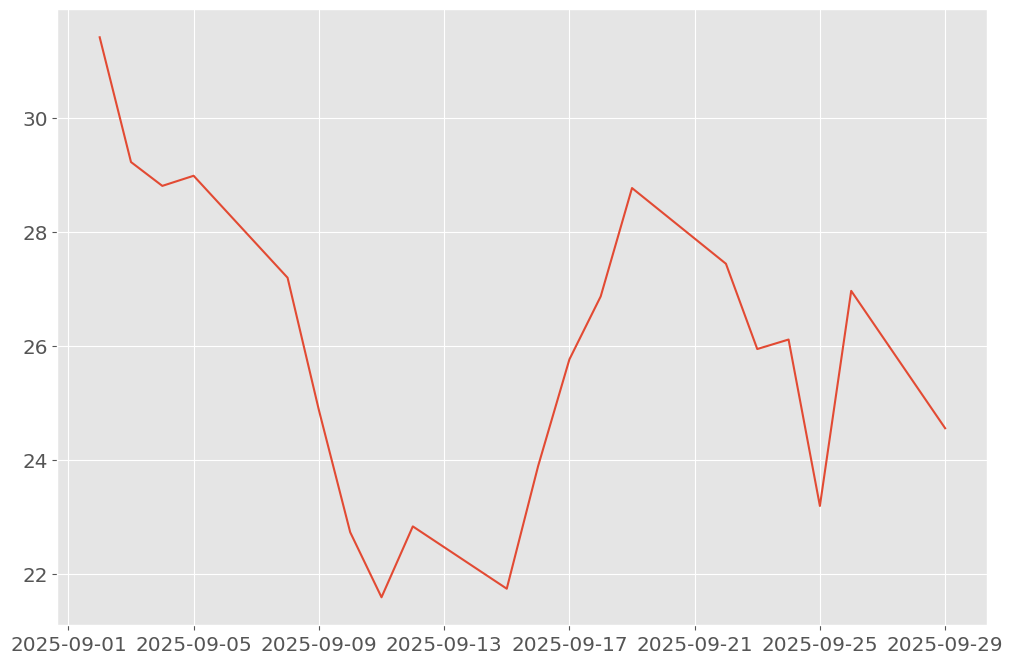

In [5]:
plt.plot(df.index, df[q.col_name()])